Found 3 test files
SAV_2025_209 (rerun of alpha-pyridone exchange with agoac)-A.CSV: y=0.8043, MAE=0.004300
SAV_2025_209 (rerun of alpha-pyridone exchange with agoac)-B.CSV: y=0.9418, MAE=0.141800
SAV_2025_209 (rerun of alpha-pyridone exchange with agoac)-C.CSV: y=0.8992, MAE=0.099151

Average MAE: 0.081751


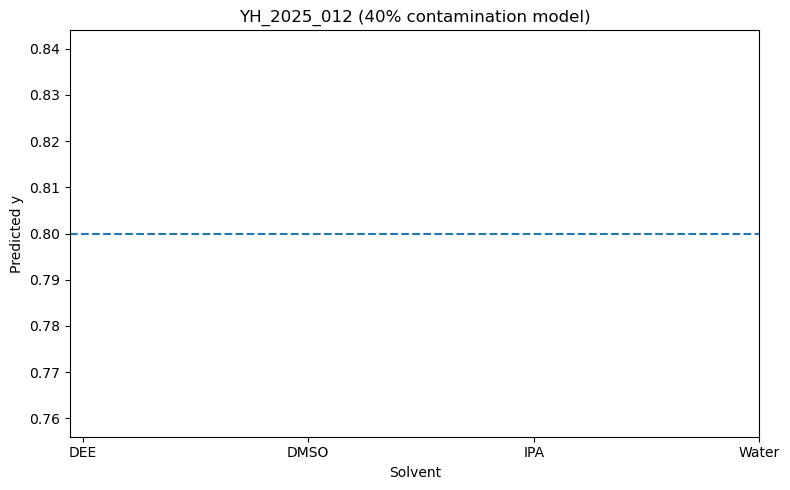

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cross_decomposition import PLSRegression
from sklearn.metrics import mean_absolute_error
from sklearn.preprocessing import StandardScaler

root_calib = '/Users/yoelhan/Documents/ChemResearch/ir_data/CD 2025 silver-pyridone calibration run/'  
solvent_dir = '/Users/yoelhan/Documents/ChemResearch/ir_data/YH_2025_007/'
test_dir = '/Users/yoelhan/Documents/ChemResearch/ir_data/SAV rerun of alpha pyridone exchange w agoac/'

n_components = 5
true_y = 0.8
alphas = np.arange(0.1, 0.5, 0.1)  # up to 40%

calib_files = sorted([f for f in os.listdir(root_calib) if f.lower().endswith('.csv')])[:33]

y_values = [
    0.1,0.1,0.1,0,0,0,1,1,1,0.9,0.9,0.9,
    0.8,0.8,0.8,0.7,0.7,0.7,0.6,0.6,0.6,
    0.5,0.5,0.5,0.4,0.4,0.4,0.3,0.3,0.3,
    0.2,0.2,0.2
]

solvent_files = [
    'YH_2025_007_DEE.csv',
    'YH_2025_007_DMSO.csv',
    'YH_2025_007_IPA.csv',
    'YH_2025_007_Water.csv'
]

# FUNCTIONS
def load_spectrum(file_path):
    data = pd.read_csv(file_path, header=None, skiprows=1)
    return data.iloc[:, 1].values

def synthesize_spectrum(calib, solvent, alpha):
    contaminated = calib + alpha * solvent
    return contaminated / (1 + alpha)

# LOAD CALIBRATION
calib_rows = []
for file, y_val in zip(calib_files, y_values):
    spectrum = load_spectrum(os.path.join(root_calib, file))
    row = np.insert(spectrum, 0, y_val)
    calib_rows.append(row)

min_len = min(len(r) for r in calib_rows)
calib_rows = [r[:min_len] for r in calib_rows]

columns = ['y'] + [f'x{i+1}' for i in range(min_len - 1)]
calib_df = pd.DataFrame(calib_rows, columns=columns)

y_calib = calib_df['y'].values
X_calib = calib_df.drop('y', axis=1).values

# LOAD SOLVENTS
solvents = {}
for file in solvent_files:
    spec = load_spectrum(os.path.join(solvent_dir, file))
    if len(spec) != X_calib.shape[1]:
        spec = np.interp(np.linspace(0,1,X_calib.shape[1]),
                         np.linspace(0,1,len(spec)), spec)
    solvents[file.split('.')[0]] = spec

# AUGMENT
X_augmented = [X_calib]
y_augmented = [y_calib]

for solvent_name, solvent_spec in solvents.items():
    for alpha in alphas:
        X_synth = np.array([
            synthesize_spectrum(x, solvent_spec, alpha)
            for x in X_calib
        ])
        X_augmented.append(X_synth)
        y_augmented.append(y_calib)

X_all = np.vstack(X_augmented)
y_all = np.concatenate(y_augmented)

scaler = StandardScaler()
X_all_scaled = scaler.fit_transform(X_all)

# MODEL
pls = PLSRegression(n_components=n_components)
pls.fit(X_all_scaled, y_all)

#Test
test_files = sorted([
    f for f in os.listdir(test_dir)
    if f.lower().endswith('.csv')
])

print(f"Found {len(test_files)} test files")

if len(test_files) == 0:
    raise ValueError(f"No CSV test files found in: {test_dir}")

predictions = []
maes = []

for file in test_files:
    spec = load_spectrum(os.path.join(test_dir, file))[:X_calib.shape[1]]
    spec_scaled = scaler.transform(spec.reshape(1, -1))
    
    y_pred = float(pls.predict(spec_scaled)[0])
    mae = mean_absolute_error([true_y], [y_pred])
    
    predictions.append((file, y_pred))
    maes.append(mae)
    
    print(f"{file}: y={y_pred:.4f}, MAE={mae:.6f}")

if len(maes) > 0:
    print(f"\nAverage MAE: {np.mean(maes):.6f}")
else:
    print("\nNo predictions made — check test data.")

#PLOT
solvent_labels = ['DEE','DMSO','IPA','Water']
x_positions = []
y_plot = []

for file, y_pred in predictions:
    for i, solvent in enumerate(solvent_labels):
        if solvent in file:
            x_positions.append(i)
            y_plot.append(y_pred)
            break

plt.figure(figsize=(8,5))
plt.scatter(x_positions, y_plot, s=80)
plt.axhline(y=true_y, linestyle='--')

plt.xticks(range(len(solvent_labels)), solvent_labels)
plt.xlabel('Solvent')
plt.ylabel('Predicted y')
plt.title('YH_2025_012 (40% contamination model)')
plt.tight_layout()
plt.show()

Calibration dataset shape:
X: (33, 7468)
y: (33,)

PLS calibration test performance:
Number of components: 5
Test MAE: 0.1055
Test R²: 0.7991

C-H activation test files:
YH_2026_020_A.CSV
YH_2026_020_B.CSV
YH_2026_020_C.CSV

C-H Activation Test Results:
           test_file  y_pred  true_y     MAE
1  YH_2026_020_A.CSV  0.5244     0.3  0.2244
2  YH_2026_020_B.CSV  0.5032     0.3  0.2032
3  YH_2026_020_C.CSV  0.2479     0.3  0.0521

Average MAE across 3 C-H activation trials: 0.1599


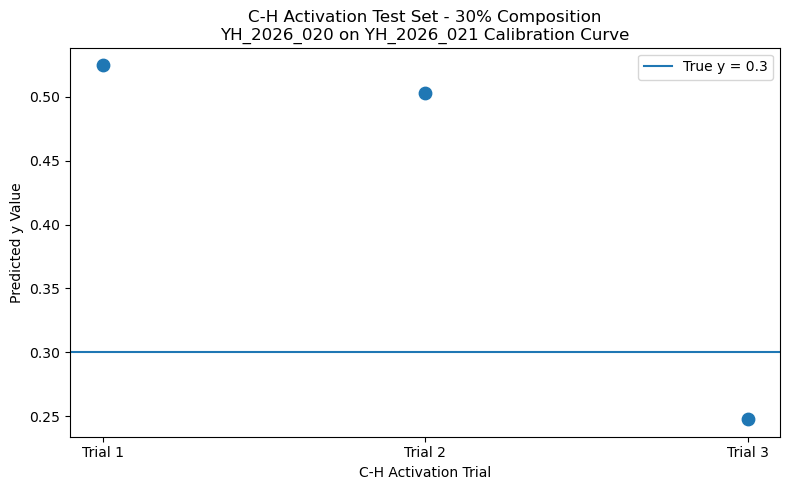

In [8]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cross_decomposition import PLSRegression
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import train_test_split


# ============================================================
# PATHS
# ============================================================

calib_dir = '/Users/yoelhan/Documents/ChemResearch/ir_data/YH_2026_021/'
test_dir = '/Users/yoelhan/Documents/ChemResearch/ir_data/YH_2026_020/'


# ============================================================
# LOAD CALIBRATION CURVE
# ============================================================

calib_files = sorted([
    file for file in os.listdir(calib_dir)
    if file.lower().endswith('.csv')
])

# Use the 33 calibration spectra
calib_files = calib_files[:33]

# Composition values for the calibration curve
#y_values = [1, 1, 1, 0.9, 0.9, 0.9, 0.8, 0.8, 0.8,
 #          0.7, 0.7, 0.7, 0.6, 0.6, 0.6, 0.5, 0.5, 0.5, 0.4, 0.4, 0.4, 
  #          0.3, 0.3, 0.3, 0.2, 0.2, 0.2, 0.1, 0.1, 0.1, 0,0,0]
            
y_values = [0,0,0, 0.1, 0.1, 0.1, 0.2, 0.2, 0.2,0.3, 0.3, 0.3,
   0.4, 0.4, 0.4,0.5, 0.5, 0.5, 0.6, 0.6, 0.6, 0.7, 0.7, 0.7,0.8, 0.8, 0.8, 0.9, 0.9, 0.9,1, 1, 1]

if len(calib_files) != len(y_values):
    raise ValueError(
        f"Number of calibration files ({len(calib_files)}) "
        f"does not match number of y values ({len(y_values)})"
    )


# ============================================================
# BUILD CALIBRATION DATASET
# ============================================================

rows = []

for file, y_value in zip(calib_files, y_values):

    file_path = os.path.join(calib_dir, file)

    data = pd.read_csv(
        file_path,
        header=None,
        skiprows=1
    )

    # IR intensity
    X_column = data.iloc[:, 1].values

    # Add y value as first column
    row = np.insert(X_column, 0, y_value)

    rows.append(row)


# Make sure all spectra have the same length
min_len = min(len(row) for row in rows)

rows = [
    row[:min_len]
    for row in rows
]


# Create dataframe
columns = ['y'] + [
    f'x{i+1}'
    for i in range(min_len - 1)
]

calib_df = pd.DataFrame(
    rows,
    columns=columns
)


# ============================================================
# SEPARATE X AND y
# ============================================================

y_calib = calib_df['y'].values

X_calib = calib_df.drop(
    'y',
    axis=1
).values


print("Calibration dataset shape:")
print("X:", X_calib.shape)
print("y:", y_calib.shape)


# ============================================================
# TRAIN / TEST SPLIT OF CALIBRATION DATA
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X_calib,
    y_calib,
    test_size=0.20,
    random_state=42
)


# ============================================================
# TRAIN PLS MODEL
# ============================================================

n_components = 5

pls = PLSRegression(
    n_components=n_components
)

pls.fit(
    X_train,
    y_train
)


# ============================================================
# TEST PLS MODEL ON HELD-OUT CALIBRATION DATA
# ============================================================

y_test_pred = pls.predict(X_test).ravel()

test_mae = mean_absolute_error(
    y_test,
    y_test_pred
)

print("\nPLS calibration test performance:")
print(f"Number of components: {n_components}")
print(f"Test MAE: {test_mae:.4f}")
print(f"Test R²: {pls.score(X_test, y_test):.4f}")


# ============================================================
# RETRAIN PLS USING ALL CALIBRATION DATA
# ============================================================

pls_final = PLSRegression(
    n_components=n_components
)

pls_final.fit(
    X_calib,
    y_calib
)


# ============================================================
# LOAD C-H ACTIVATION TEST SET
# ============================================================

test_files = sorted([
    file for file in os.listdir(test_dir)
    if file.lower().endswith('.csv')
])

# There should be 3 trials
test_files = test_files[:3]

print("\nC-H activation test files:")
for file in test_files:
    print(file)


# ============================================================
# LOAD TEST SPECTRA
# ============================================================

spectra = []

for file in test_files:

    file_path = os.path.join(
        test_dir,
        file
    )

    data = pd.read_csv(
        file_path,
        header=None,
        skiprows=1
    )

    x_column = data.iloc[:, 1].values

    # Trim to same number of features as calibration
    spectra.append(
        x_column[:min_len - 1]
    )


spectra_df = pd.DataFrame(
    spectra,
    columns=[
        f'x{i+1}'
        for i in range(min_len - 1)
    ]
)


# ============================================================
# PREDICT C-H ACTIVATION SAMPLES
# ============================================================

y_pred = pls_final.predict(
    spectra_df.values
).ravel()


# True composition = 30%
#true_y = 0.30


# ============================================================
# CALCULATE MAE
# ============================================================

mae_list = []
results = []

for file, y_pre in zip(test_files, y_pred):

    mae = mean_absolute_error(
        [true_y],
        [y_pre]
    )

    mae_list.append(mae)

    results.append({
        'test_file': file,
        'y_pred': y_pre,
        'true_y': true_y,
        'MAE': mae
    })


# ============================================================
# RESULTS TABLE
# ============================================================

results_df = pd.DataFrame(results)

# Start index at 1 instead of 0
results_df.index = results_df.index + 1

results_df[
    ['y_pred', 'true_y', 'MAE']
] = results_df[
    ['y_pred', 'true_y', 'MAE']
].round(4)


print("\nC-H Activation Test Results:")
print(results_df)


# ============================================================
# AVERAGE MAE
# ============================================================

avg_mae = np.mean(mae_list)

print(
    f"\nAverage MAE across 3 C-H activation trials: "
    f"{avg_mae:.4f}"
)


# ============================================================
# PLOT
# ============================================================

plt.figure(figsize=(8, 5))

plt.scatter(
    range(1, len(y_pred) + 1),
    y_pred,
    s=80
)

plt.axhline(
    y=true_y,
    #linestyle='--',
    label=f'True y = {true_y}'
)

plt.xticks(
    range(1, len(y_pred) + 1),
    [f'Trial {i}' for i in range(1, len(y_pred) + 1)]
)

plt.xlabel('C-H Activation Trial')
plt.ylabel('Predicted y Value')

plt.title(
    'C-H Activation Test Set - 30% Composition\n'
    'YH_2026_020 on YH_2026_021 Calibration Curve'
)

plt.legend()
plt.tight_layout()
plt.show()

/Users/yoelhan/Documents/ChemResearch/ir_data/YH_2026_022/YH_2026_022_002_A.CSV
/Users/yoelhan/Documents/ChemResearch/ir_data/YH_2026_022/YH_2026_022_002_B.CSV
/Users/yoelhan/Documents/ChemResearch/ir_data/YH_2026_022/YH_2026_022_002_C.CSV
/Users/yoelhan/Documents/ChemResearch/ir_data/YH_2026_022/YH_2026_022_003_A.CSV
/Users/yoelhan/Documents/ChemResearch/ir_data/YH_2026_022/YH_2026_022_003_B.CSV
/Users/yoelhan/Documents/ChemResearch/ir_data/YH_2026_022/YH_2026_022_003_C.CSV
/Users/yoelhan/Documents/ChemResearch/ir_data/YH_2026_022/YH_2026_022_004_A.CSV
/Users/yoelhan/Documents/ChemResearch/ir_data/YH_2026_022/YH_2026_022_004_B.CSV
/Users/yoelhan/Documents/ChemResearch/ir_data/YH_2026_022/YH_2026_022_004_C.CSV
/Users/yoelhan/Documents/ChemResearch/ir_data/YH_2026_022/YH_2026_022_005_A.CSV
/Users/yoelhan/Documents/ChemResearch/ir_data/YH_2026_022/YH_2026_022_005_B.CSV
/Users/yoelhan/Documents/ChemResearch/ir_data/YH_2026_022/YH_2026_022_005_C.CSV
/Users/yoelhan/Documents/ChemResearch/ir

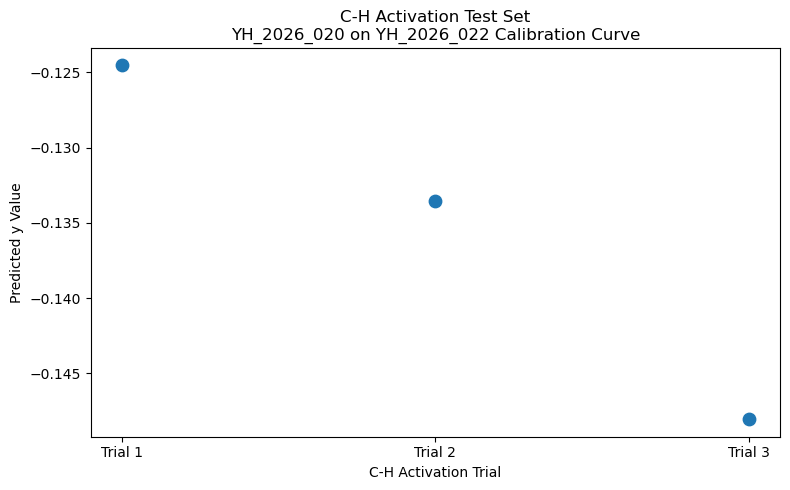

In [2]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cross_decomposition import PLSRegression
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import train_test_split


# ============================================================
# PATHS
# ============================================================

calib_dir = '/Users/yoelhan/Documents/ChemResearch/ir_data/YH_2026_022/'
test_dir = '/Users/yoelhan/Documents/ChemResearch/ir_data/YH_2026_020/'


# ============================================================
# LOAD CALIBRATION CURVE
# ============================================================

calib_files = sorted([
    file for file in os.listdir(calib_dir)
    if file.lower().endswith('.csv')
])

# Use the 33 calibration spectra
calib_files = calib_files[:33]

# Composition values for the calibration curve
#y_values = [1, 1, 1, 0.9, 0.9, 0.9, 0.8, 0.8, 0.8,
 #          0.7, 0.7, 0.7, 0.6, 0.6, 0.6, 0.5, 0.5, 0.5, 0.4, 0.4, 0.4, 
  #          0.3, 0.3, 0.3, 0.2, 0.2, 0.2, 0.1, 0.1, 0.1, 0,0,0]
            
y_values = [ 0.1, 0.1, 0.1, 0.2, 0.2, 0.2,0.3, 0.3, 0.3,
   0.4, 0.4, 0.4,0.5, 0.5, 0.5, 0.6, 0.6, 0.6, 0.7, 0.7, 0.7,0.8, 0.8, 0.8, 0.9, 0.9, 0.9,1, 1, 1, 0,0,0]

if len(calib_files) != len(y_values):
    raise ValueError(
        f"Number of calibration files ({len(calib_files)}) "
        f"does not match number of y values ({len(y_values)})"
    )


# ============================================================
# BUILD CALIBRATION DATASET
# ============================================================

rows = []

for file, y_value in zip(calib_files, y_values):

    file_path = os.path.join(calib_dir, file)
    print(file_path)
    data = pd.read_csv(
        file_path,
        header=None,
        skiprows=1
    )

    # IR intensity
    X_column = data.iloc[:, 1].values

    # Add y value as first column
    row = np.insert(X_column, 0, y_value)

    rows.append(row)


# Make sure all spectra have the same length
min_len = min(len(row) for row in rows)

rows = [
    row[:min_len]
    for row in rows
]


# Create dataframe
columns = ['y'] + [
    f'x{i+1}'
    for i in range(min_len - 1)
]

calib_df = pd.DataFrame(
    rows,
    columns=columns
)


# ============================================================
# SEPARATE X AND y
# ============================================================

y_calib = calib_df['y'].values

X_calib = calib_df.drop(
    'y',
    axis=1
).values


print("Calibration dataset shape:")
print("X:", X_calib.shape)
print("y:", y_calib.shape)


# ============================================================
# TRAIN / TEST SPLIT OF CALIBRATION DATA
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X_calib,
    y_calib,
    test_size=0.20,
    random_state=42
)


# ============================================================
# TRAIN PLS MODEL
# ============================================================

n_components = 5

pls = PLSRegression(
    n_components=n_components
)

pls.fit(
    X_train,
    y_train
)


# ============================================================
# TEST PLS MODEL ON HELD-OUT CALIBRATION DATA
# ============================================================

y_test_pred = pls.predict(X_test).ravel()

test_mae = mean_absolute_error(
    y_test,
    y_test_pred
)

print("\nPLS calibration test performance:")
print(f"Number of components: {n_components}")
print(f"Test MAE: {test_mae:.4f}")
print(f"Test R²: {pls.score(X_test, y_test):.4f}")


# ============================================================
# RETRAIN PLS USING ALL CALIBRATION DATA
# ============================================================

pls_final = PLSRegression(
    n_components=n_components
)

pls_final.fit(
    X_calib,
    y_calib
)


# ============================================================
# LOAD C-H ACTIVATION TEST SET
# ============================================================

test_files = sorted([
    file for file in os.listdir(test_dir)
    if file.lower().endswith('.csv')
])

# There should be 3 trials
test_files = test_files[:3]

print("\nC-H activation test files:")
for file in test_files:
    print(file)


# ============================================================
# LOAD TEST SPECTRA
# ============================================================

spectra = []

for file in test_files:

    file_path = os.path.join(
        test_dir,
        file
    )

    data = pd.read_csv(
        file_path,
        header=None,
        skiprows=1
    )

    x_column = data.iloc[:, 1].values

    # Trim to same number of features as calibration
    spectra.append(
        x_column[:min_len - 1]
    )


spectra_df = pd.DataFrame(
    spectra,
    columns=[
        f'x{i+1}'
        for i in range(min_len - 1)
    ]
)


# ============================================================
# PREDICT C-H ACTIVATION SAMPLES
# ============================================================

y_pred = pls_final.predict(
    spectra_df.values
).ravel()


# ============================================================
# RESULTS TABLE
# ============================================================

results = []

for file, y_pre in zip(test_files, y_pred):

    results.append({
        'test_file': file,
        'y_pred': y_pre
    })


results_df = pd.DataFrame(results)

# Start index at 1 instead of 0
results_df.index = results_df.index + 1

results_df['y_pred'] = results_df['y_pred'].round(4)


print("\nC-H Activation Test Results:")
print(results_df)


# ============================================================
# PLOT
# ============================================================

plt.figure(figsize=(8, 5))

plt.scatter(
    range(1, len(y_pred) + 1),
    y_pred,
    s=80
)

plt.xticks(
    range(1, len(y_pred) + 1),
    [f'Trial {i}' for i in range(1, len(y_pred) + 1)]
)

plt.xlabel('C-H Activation Trial')
plt.ylabel('Predicted y Value')

plt.title(
    'C-H Activation Test Set\n'
    'YH_2026_020 on YH_2026_022 Calibration Curve'
)

plt.tight_layout()
plt.show()


Calibration file → y value:
YH_2026_022_002_A.CSV -> 0.1
YH_2026_022_002_B.CSV -> 0.1
YH_2026_022_002_C.CSV -> 0.1
YH_2026_022_003_A.CSV -> 0.2
YH_2026_022_003_B.CSV -> 0.2
YH_2026_022_003_C.CSV -> 0.2
YH_2026_022_004_A.CSV -> 0.3
YH_2026_022_004_B.CSV -> 0.3
YH_2026_022_004_C.CSV -> 0.3
YH_2026_022_005_A.CSV -> 0.4
YH_2026_022_005_B.CSV -> 0.4
YH_2026_022_005_C.CSV -> 0.4
YH_2026_022_006_A.CSV -> 0.5
YH_2026_022_006_B.CSV -> 0.5
YH_2026_022_006_C.CSV -> 0.5
YH_2026_022_007_A.CSV -> 0.6
YH_2026_022_007_B.CSV -> 0.6
YH_2026_022_007_C.CSV -> 0.6
YH_2026_022_008_A.CSV -> 0.7
YH_2026_022_008_B.CSV -> 0.7
YH_2026_022_008_C.CSV -> 0.7
YH_2026_022_009_A.CSV -> 0.8
YH_2026_022_009_B.CSV -> 0.8
YH_2026_022_009_C.CSV -> 0.8
YH_2026_022_010_A.CSV -> 0.9
YH_2026_022_010_B.CSV -> 0.9
YH_2026_022_010_C.CSV -> 0.9
YH_2026_022_011_A.CSV -> 1.0
YH_2026_022_011_B.CSV -> 1.0
YH_2026_022_011_C.CSV -> 1.0
YH_2026_022_AgOAc_A.CSV -> 0.0
YH_2026_022_AgOAc_B.CSV -> 0.0
YH_2026_022_AgOAc_C.CSV -> 0.0

Calibra

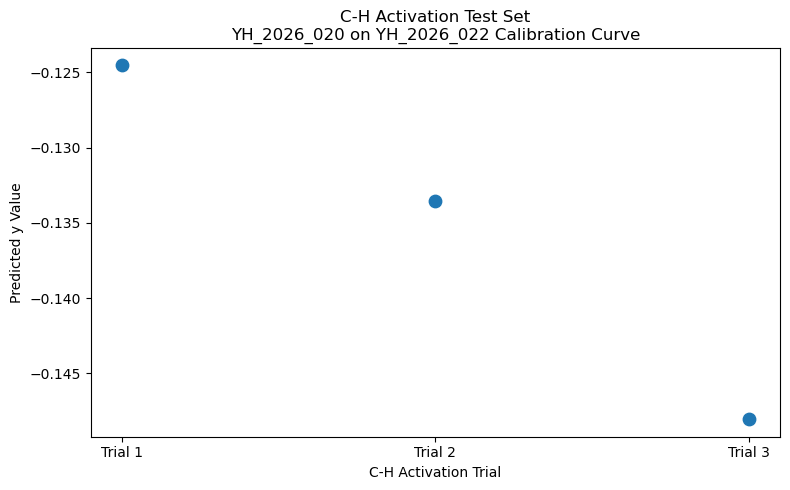

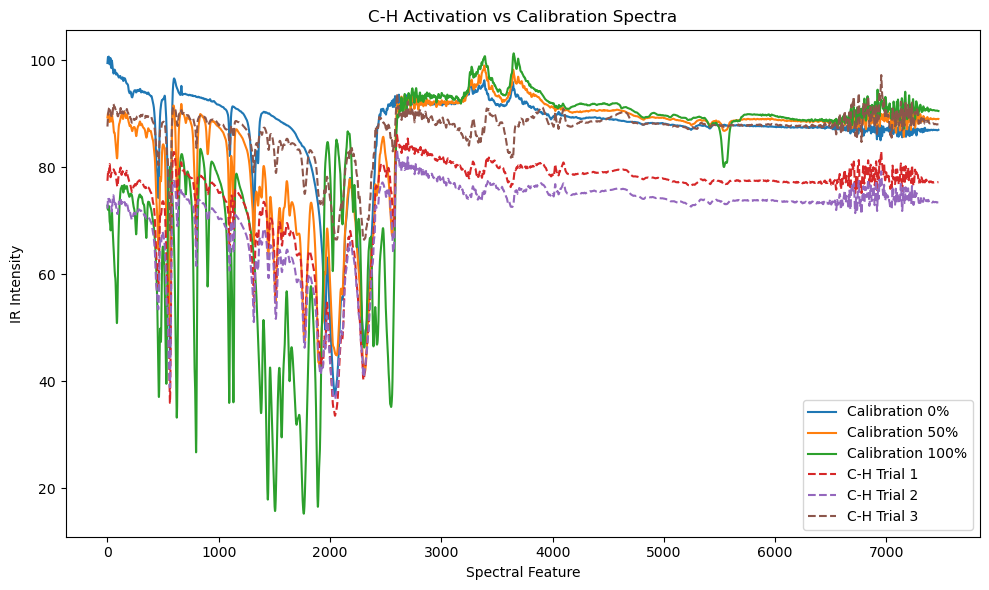

In [4]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cross_decomposition import PLSRegression
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import train_test_split


# ============================================================
# PATHS
# ============================================================

calib_dir = '/Users/yoelhan/Documents/ChemResearch/ir_data/YH_2026_022/'
test_dir = '/Users/yoelhan/Documents/ChemResearch/ir_data/YH_2026_020/'


# ============================================================
# LOAD CALIBRATION CURVE
# ============================================================

calib_files = sorted([
    file for file in os.listdir(calib_dir)
    if file.lower().endswith('.csv')
])

calib_files = calib_files[:33]


# ============================================================
# CALIBRATION y VALUES
# ============================================================
#
# YH_2026_022:
#
# 002 = 0.1
# 003 = 0.2
# 004 = 0.3
# 005 = 0.4
# 006 = 0.5
# 007 = 0.6
# 008 = 0.7
# 009 = 0.8
# 010 = 0.9
# 011 = 1.0
# AgOAc = 0.0
#
# Each composition has 3 trials.
# ============================================================

y_values = [
    0.1, 0.1, 0.1,
    0.2, 0.2, 0.2,
    0.3, 0.3, 0.3,
    0.4, 0.4, 0.4,
    0.5, 0.5, 0.5,
    0.6, 0.6, 0.6,
    0.7, 0.7, 0.7,
    0.8, 0.8, 0.8,
    0.9, 0.9, 0.9,
    1.0, 1.0, 1.0,
    0.0, 0.0, 0.0
]


if len(calib_files) != len(y_values):
    raise ValueError(
        f"Number of calibration files ({len(calib_files)}) "
        f"does not match number of y values ({len(y_values)})"
    )


# ============================================================
# CHECK FILE → Y ASSIGNMENT
# ============================================================

print("\nCalibration file → y value:")

for file, y_value in zip(calib_files, y_values):
    print(f"{file} -> {y_value}")


# ============================================================
# BUILD CALIBRATION DATASET
# ============================================================

rows = []

for file, y_value in zip(calib_files, y_values):

    file_path = os.path.join(
        calib_dir,
        file
    )

    data = pd.read_csv(
        file_path,
        header=None,
        skiprows=1
    )

    # IR intensity
    X_column = data.iloc[:, 1].values

    # Add y value as first column
    row = np.insert(
        X_column,
        0,
        y_value
    )

    rows.append(row)


# ============================================================
# MAKE ALL SPECTRA THE SAME LENGTH
# ============================================================

min_len = min(
    len(row)
    for row in rows
)

rows = [
    row[:min_len]
    for row in rows
]


# ============================================================
# CREATE CALIBRATION DATAFRAME
# ============================================================

columns = ['y'] + [
    f'x{i+1}'
    for i in range(min_len - 1)
]

calib_df = pd.DataFrame(
    rows,
    columns=columns
)


# ============================================================
# SEPARATE X AND y
# ============================================================

y_calib = calib_df['y'].values

X_calib = calib_df.drop(
    'y',
    axis=1
).values


print("\nCalibration dataset shape:")
print("X:", X_calib.shape)
print("y:", y_calib.shape)


# ============================================================
# TRAIN / TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X_calib,
    y_calib,
    test_size=0.20,
    random_state=42
)


# ============================================================
# TRAIN PLS MODEL
# ============================================================

n_components = 5

pls = PLSRegression(
    n_components=n_components
)

pls.fit(
    X_train,
    y_train
)


# ============================================================
# TEST PLS MODEL
# ============================================================

y_test_pred = pls.predict(
    X_test
).ravel()

test_mae = mean_absolute_error(
    y_test,
    y_test_pred
)

test_r2 = pls.score(
    X_test,
    y_test
)

print("\nPLS calibration test performance:")
print(f"Number of components: {n_components}")
print(f"Test MAE: {test_mae:.4f}")
print(f"Test R²: {test_r2:.4f}")


# ============================================================
# RETRAIN USING ALL CALIBRATION DATA
# ============================================================

pls_final = PLSRegression(
    n_components=n_components
)

pls_final.fit(
    X_calib,
    y_calib
)


# ============================================================
# LOAD C-H ACTIVATION TEST SET
# ============================================================

test_files = sorted([
    file for file in os.listdir(test_dir)
    if file.lower().endswith('.csv')
])

test_files = test_files[:3]


print("\nC-H activation test files:")

for file in test_files:
    print(file)


# ============================================================
# LOAD TEST SPECTRA
# ============================================================

spectra = []

for file in test_files:

    file_path = os.path.join(
        test_dir,
        file
    )

    data = pd.read_csv(
        file_path,
        header=None,
        skiprows=1
    )

    x_column = data.iloc[:, 1].values

    # Trim to calibration length
    spectra.append(
        x_column[:min_len - 1]
    )


spectra_df = pd.DataFrame(
    spectra,
    columns=[
        f'x{i+1}'
        for i in range(min_len - 1)
    ]
)


# ============================================================
# PREDICT C-H ACTIVATION SAMPLES
# ============================================================

y_pred = pls_final.predict(
    spectra_df.values
).ravel()


# ============================================================
# RESULTS
# ============================================================

results = []

for file, y_pre in zip(
    test_files,
    y_pred
):

    results.append({
        'test_file': file,
        'y_pred': y_pre
    })


results_df = pd.DataFrame(
    results
)

# Start index at 1
results_df.index = results_df.index + 1

results_df['y_pred'] = (
    results_df['y_pred']
    .round(4)
)


print("\nC-H Activation Test Results:")
print(results_df)


# ============================================================
# PLOT
# ============================================================

plt.figure(
    figsize=(8, 5)
)

plt.scatter(
    range(1, len(y_pred) + 1),
    y_pred,
    s=80
)

plt.xticks(
    range(1, len(y_pred) + 1),
    [
        f'Trial {i}'
        for i in range(1, len(y_pred) + 1)
    ]
)

plt.xlabel(
    'C-H Activation Trial'
)

plt.ylabel(
    'Predicted y Value'
)

plt.title(
    'C-H Activation Test Set\n'
    'YH_2026_020 on YH_2026_022 Calibration Curve'
)

plt.tight_layout()
plt.show()

# ============================================================
# COMPARE KEY CALIBRATION POINTS WITH C-H ACTIVATION
# ============================================================

plt.figure(figsize=(10, 6))

# 0% AgOAc
plt.plot(
    X_calib[30],
    label='Calibration 0%'
)

# 50% calibration
plt.plot(
    X_calib[14],
    label='Calibration 50%'
)

# 100% calibration
plt.plot(
    X_calib[29],
    label='Calibration 100%'
)

# C-H activation trials
for i in range(len(spectra)):
    plt.plot(
        spectra[i],
        linestyle='--',
        label=f'C-H Trial {i+1}'
    )

plt.xlabel('Spectral Feature')
plt.ylabel('IR Intensity')

plt.title(
    'C-H Activation vs Calibration Spectra'
)

plt.legend()
plt.tight_layout()
plt.show()


CALIBRATION FILE → Y VALUE
YH_2026_022_002_A.CSV -> 0.1
YH_2026_022_002_B.CSV -> 0.1
YH_2026_022_002_C.CSV -> 0.1
YH_2026_022_003_A.CSV -> 0.2
YH_2026_022_003_B.CSV -> 0.2
YH_2026_022_003_C.CSV -> 0.2
YH_2026_022_004_A.CSV -> 0.3
YH_2026_022_004_B.CSV -> 0.3
YH_2026_022_004_C.CSV -> 0.3
YH_2026_022_005_A.CSV -> 0.4
YH_2026_022_005_B.CSV -> 0.4
YH_2026_022_005_C.CSV -> 0.4
YH_2026_022_006_A.CSV -> 0.5
YH_2026_022_006_B.CSV -> 0.5
YH_2026_022_006_C.CSV -> 0.5
YH_2026_022_007_A.CSV -> 0.6
YH_2026_022_007_B.CSV -> 0.6
YH_2026_022_007_C.CSV -> 0.6
YH_2026_022_008_A.CSV -> 0.7
YH_2026_022_008_B.CSV -> 0.7
YH_2026_022_008_C.CSV -> 0.7
YH_2026_022_009_A.CSV -> 0.8
YH_2026_022_009_B.CSV -> 0.8
YH_2026_022_009_C.CSV -> 0.8
YH_2026_022_010_A.CSV -> 0.9
YH_2026_022_010_B.CSV -> 0.9
YH_2026_022_010_C.CSV -> 0.9
YH_2026_022_011_A.CSV -> 1.0
YH_2026_022_011_B.CSV -> 1.0
YH_2026_022_011_C.CSV -> 1.0
YH_2026_022_AgOAc_A.CSV -> 0.0
YH_2026_022_AgOAc_B.CSV -> 0.0
YH_2026_022_AgOAc_C.CSV -> 0.0

CALIBRAT

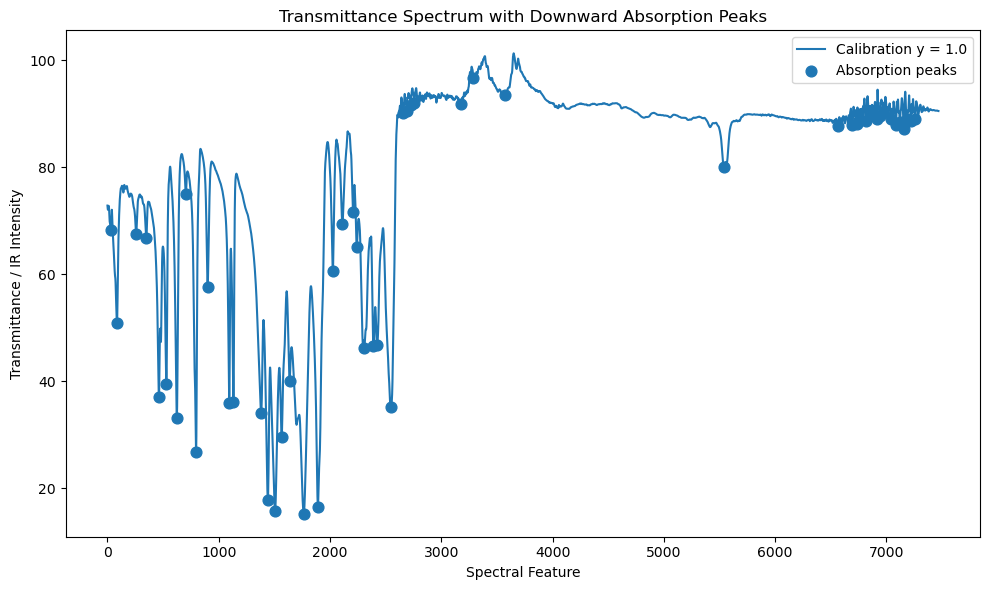


PLS CALIBRATION TEST PERFORMANCE
Number of components: 5
Test MAE: 0.0316
Test R²: 0.9819

C-H ACTIVATION TEST FILES
YH_2026_020_A.CSV
YH_2026_020_B.CSV
YH_2026_020_C.CSV

C-H ACTIVATION TRANSMITTANCE MAGNITUDE CHECK
Trial 1 | minimum = 33.552010 | maximum = 86.040780 | mean = 75.016817
Trial 2 | minimum = 36.648310 | maximum = 83.137920 | mean = 71.174138
Trial 3 | minimum = 66.464570 | maximum = 97.248120 | mean = 86.996063

C-H ACTIVATION TEST RESULTS
           test_file  y_pred
1  YH_2026_020_A.CSV -0.1245
2  YH_2026_020_B.CSV -0.1336
3  YH_2026_020_C.CSV -0.1480


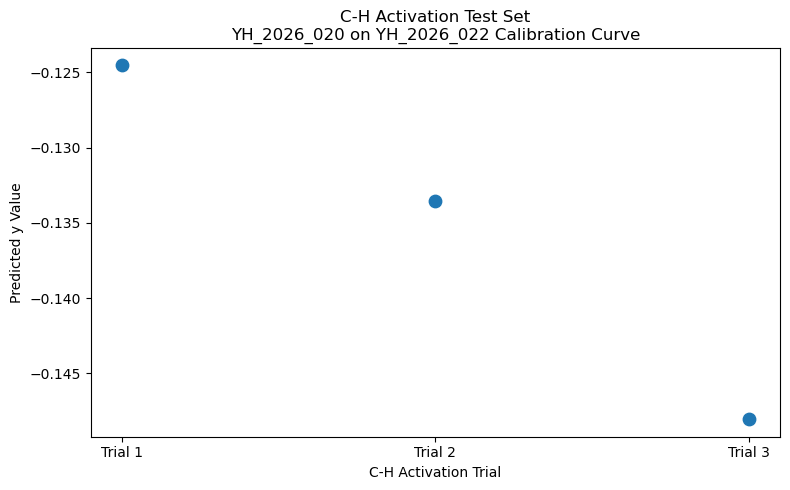

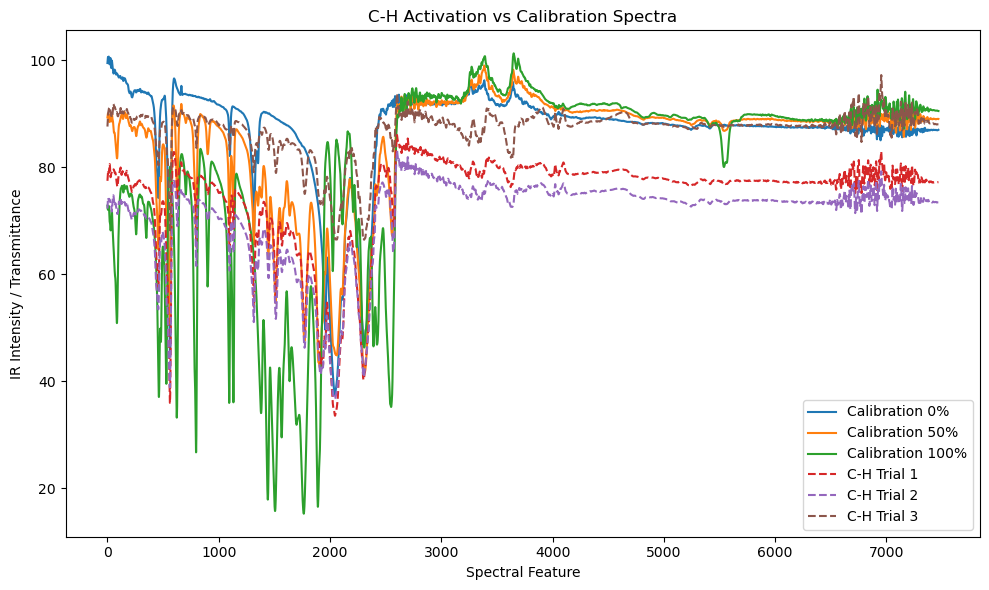

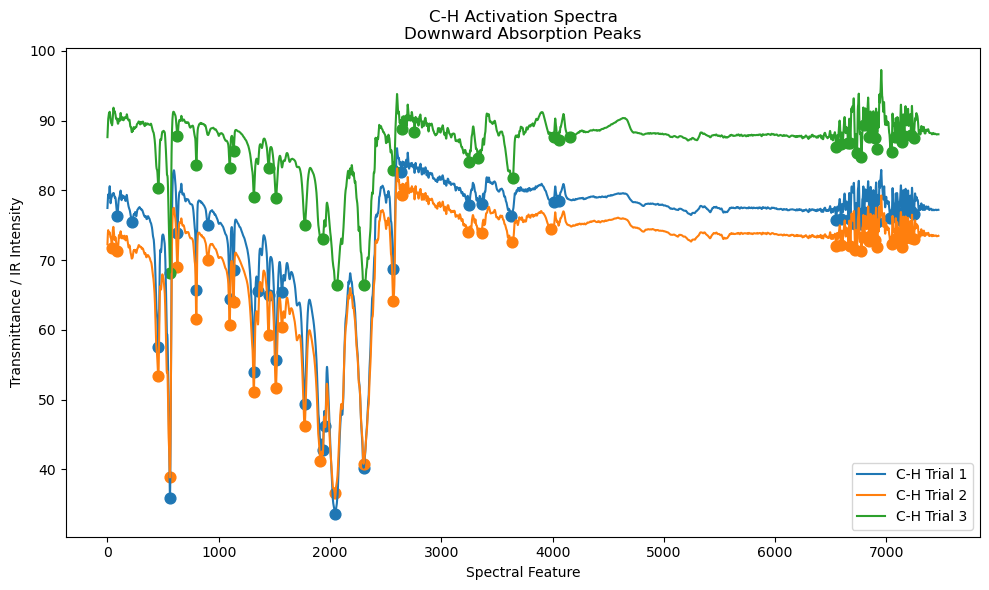


C-H ACTIVATION PEAK / BASELINE SUMMARY
Trial 1 | Detected peaks = 44 | Strongest absorption T = 33.5520 | Largest peak depth = 46.9065
Trial 2 | Detected peaks = 40 | Strongest absorption T = 36.6483 | Largest peak depth = 38.6295
Trial 3 | Detected peaks = 40 | Strongest absorption T = 66.4646 | Largest peak depth = 23.0381

MAGNITUDE INTERPRETATION

The IR data are treated as TRANSMITTANCE.

For transmittance:
    HIGHER number = HIGHER transmittance
    LOWER number  = STRONGER absorption

Therefore:
    Absorption peak = LOCAL MINIMUM
    Strongest absorption = np.argmin(spectrum)
    Multiple absorption peaks = find_peaks(-spectrum)

Peak depth:
    baseline - peak

A larger peak depth means stronger absorption.

The raw transmittance values are NOT inverted before PLS.
The negative sign is used ONLY for peak detection.

Therefore, the PLS model is still predicting directly
from the measured transmittance spectra.



In [2]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scipy.signal import find_peaks

from sklearn.cross_decomposition import PLSRegression
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import train_test_split


# ============================================================
# PATHS
# ============================================================

calib_dir = '/Users/yoelhan/Documents/ChemResearch/ir_data/YH_2026_022/'
test_dir = '/Users/yoelhan/Documents/ChemResearch/ir_data/YH_2026_020/'


# ============================================================
# LOAD CALIBRATION CURVE
# ============================================================

calib_files = sorted([
    file for file in os.listdir(calib_dir)
    if file.lower().endswith('.csv')
])

calib_files = calib_files[:33]


# ============================================================
# CALIBRATION y VALUES
# ============================================================

y_values = [
    0.1, 0.1, 0.1,
    0.2, 0.2, 0.2,
    0.3, 0.3, 0.3,
    0.4, 0.4, 0.4,
    0.5, 0.5, 0.5,
    0.6, 0.6, 0.6,
    0.7, 0.7, 0.7,
    0.8, 0.8, 0.8,
    0.9, 0.9, 0.9,
    1.0, 1.0, 1.0,
    0.0, 0.0, 0.0
]


if len(calib_files) != len(y_values):
    raise ValueError(
        f"Number of calibration files ({len(calib_files)}) "
        f"does not match number of y values ({len(y_values)})"
    )


# ============================================================
# CHECK FILE → Y ASSIGNMENT
# ============================================================

print("\n============================================================")
print("CALIBRATION FILE → Y VALUE")
print("============================================================")

for file, y_value in zip(calib_files, y_values):
    print(f"{file} -> {y_value}")


# ============================================================
# BUILD CALIBRATION DATASET
# ============================================================

rows = []

for file, y_value in zip(calib_files, y_values):

    file_path = os.path.join(
        calib_dir,
        file
    )

    data = pd.read_csv(
        file_path,
        header=None,
        skiprows=1
    )

    # Raw IR intensity / transmittance
    X_column = data.iloc[:, 1].values

    # Add y value as first column
    row = np.insert(
        X_column,
        0,
        y_value
    )

    rows.append(row)


# ============================================================
# MAKE ALL SPECTRA THE SAME LENGTH
# ============================================================

min_len = min(
    len(row)
    for row in rows
)

rows = [
    row[:min_len]
    for row in rows
]


# ============================================================
# CREATE CALIBRATION DATAFRAME
# ============================================================

columns = ['y'] + [
    f'x{i+1}'
    for i in range(min_len - 1)
]

calib_df = pd.DataFrame(
    rows,
    columns=columns
)


# ============================================================
# SEPARATE X AND y
# ============================================================

y_calib = calib_df['y'].values

X_calib = calib_df.drop(
    'y',
    axis=1
).values


print("\n============================================================")
print("CALIBRATION DATASET")
print("============================================================")

print("X shape:", X_calib.shape)
print("y shape:", y_calib.shape)

print("\nTransmittance magnitude check:")
print(f"Minimum intensity: {X_calib.min():.6f}")
print(f"Maximum intensity: {X_calib.max():.6f}")
print(f"Mean intensity:    {X_calib.mean():.6f}")


# ============================================================
# PEAK DETECTION FOR TRANSMITTANCE
# ============================================================
#
# The spectrometer measures transmittance.
#
# Absorption features point DOWNWARD.
#
# Therefore:
#
#     find_peaks(-spectrum)
#
# is used to detect absorption peaks.
#
# The raw X values are NOT inverted for PLS.
# ============================================================

def find_transmittance_peaks(
    spectrum,
    prominence=2,
    distance=20
):

    inverted_spectrum = -spectrum

    peak_indices, properties = find_peaks(
        inverted_spectrum,
        prominence=prominence,
        distance=distance
    )

    return peak_indices, properties


# ============================================================
# CALCULATE PEAK / BASELINE INFORMATION
# ============================================================
#
# Peak:
#     Local minimum in transmittance
#
# Baseline:
#     Local high transmittance surrounding the absorption
#
# Peak depth:
#
#     baseline - peak
#
# Larger peak depth = stronger absorption.
# ============================================================

def calculate_peak_depths(
    spectrum,
    peak_indices,
    window=50
):

    peak_results = []

    for peak_index in peak_indices:

        left_start = max(
            0,
            peak_index - window
        )

        right_end = min(
            len(spectrum),
            peak_index + window + 1
        )

        local_region = spectrum[
            left_start:right_end
        ]

        baseline = np.max(
            local_region
        )

        peak_value = spectrum[
            peak_index
        ]

        peak_depth = (
            baseline - peak_value
        )

        peak_results.append({
            'peak_index': peak_index,
            'peak_transmittance': peak_value,
            'baseline_transmittance': baseline,
            'peak_depth': peak_depth
        })

    return peak_results


# ============================================================
# STRONGEST ABSORPTION CHECK
# ============================================================
#
# For transmittance:
#
#     lower number = stronger absorption
#
# Therefore:
#
#     np.argmin(spectrum)
#
# identifies the strongest absorption feature.
# ============================================================

print("\n============================================================")
print("CALIBRATION MAGNITUDE CHECK")
print("============================================================")

for i, spectrum in enumerate(X_calib):

    strongest_peak_index = np.argmin(
        spectrum
    )

    strongest_peak_value = spectrum[
        strongest_peak_index
    ]

    print(
        f"Calibration {i+1:02d} | "
        f"y = {y_calib[i]:.1f} | "
        f"minimum = {strongest_peak_value:.4f}"
    )


# ============================================================
# PLOT EXAMPLE CALIBRATION SPECTRUM
# ============================================================

example_index = 29

example_spectrum = X_calib[
    example_index
]

peak_indices, properties = find_transmittance_peaks(
    example_spectrum,
    prominence=2,
    distance=20
)

plt.figure(
    figsize=(10, 6)
)

plt.plot(
    example_spectrum,
    label=f'Calibration y = {y_calib[example_index]:.1f}'
)

plt.scatter(
    peak_indices,
    example_spectrum[peak_indices],
    s=60,
    label='Absorption peaks'
)

plt.xlabel(
    'Spectral Feature'
)

plt.ylabel(
    'Transmittance / IR Intensity'
)

plt.title(
    'Transmittance Spectrum with Downward Absorption Peaks'
)

plt.legend()

plt.tight_layout()

plt.show()


# ============================================================
# TRAIN / TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X_calib,
    y_calib,
    test_size=0.20,
    random_state=42
)


# ============================================================
# TRAIN PLS MODEL
# ============================================================

n_components = 5

pls = PLSRegression(
    n_components=n_components
)

pls.fit(
    X_train,
    y_train
)


# ============================================================
# TEST PLS MODEL
# ============================================================

y_test_pred = pls.predict(
    X_test
).ravel()

test_mae = mean_absolute_error(
    y_test,
    y_test_pred
)

test_r2 = pls.score(
    X_test,
    y_test
)


print("\n============================================================")
print("PLS CALIBRATION TEST PERFORMANCE")
print("============================================================")

print(
    f"Number of components: {n_components}"
)

print(
    f"Test MAE: {test_mae:.4f}"
)

print(
    f"Test R²: {test_r2:.4f}"
)


# ============================================================
# RETRAIN USING ALL CALIBRATION DATA
# ============================================================

pls_final = PLSRegression(
    n_components=n_components
)

pls_final.fit(
    X_calib,
    y_calib
)


# ============================================================
# LOAD C-H ACTIVATION TEST SET
# ============================================================

test_files = sorted([
    file for file in os.listdir(test_dir)
    if file.lower().endswith('.csv')
])

test_files = test_files[:3]


print("\n============================================================")
print("C-H ACTIVATION TEST FILES")
print("============================================================")

for file in test_files:
    print(file)


# ============================================================
# LOAD TEST SPECTRA
# ============================================================

spectra = []

for file in test_files:

    file_path = os.path.join(
        test_dir,
        file
    )

    data = pd.read_csv(
        file_path,
        header=None,
        skiprows=1
    )

    x_column = data.iloc[:, 1].values

    spectra.append(
        x_column[:min_len - 1]
    )


spectra_df = pd.DataFrame(
    spectra,
    columns=[
        f'x{i+1}'
        for i in range(min_len - 1)
    ]
)


# ============================================================
# TEST SPECTRA MAGNITUDE CHECK
# ============================================================

print("\n============================================================")
print("C-H ACTIVATION TRANSMITTANCE MAGNITUDE CHECK")
print("============================================================")

for i, spectrum in enumerate(spectra):

    print(
        f"Trial {i+1} | "
        f"minimum = {np.min(spectrum):.6f} | "
        f"maximum = {np.max(spectrum):.6f} | "
        f"mean = {np.mean(spectrum):.6f}"
    )


# ============================================================
# FIND C-H ACTIVATION PEAKS
# ============================================================
#
# Peaks are found using -spectrum because the data are
# transmittance.
#
# We calculate them here for analysis but do not print
# every individual peak.
# ============================================================

ch_peak_results = []

for i, spectrum in enumerate(spectra):

    peak_indices, properties = find_transmittance_peaks(
        spectrum,
        prominence=2,
        distance=20
    )

    peak_results = calculate_peak_depths(
        spectrum,
        peak_indices,
        window=50
    )

    ch_peak_results.append(
        peak_results
    )


# ============================================================
# PREDICT C-H ACTIVATION SAMPLES
# ============================================================

y_pred = pls_final.predict(
    spectra_df.values
).ravel()


# ============================================================
# RESULTS
# ============================================================

results = []

for file, y_pre in zip(
    test_files,
    y_pred
):

    results.append({
        'test_file': file,
        'y_pred': y_pre
    })


results_df = pd.DataFrame(
    results
)

# Start index at 1
results_df.index = results_df.index + 1

results_df['y_pred'] = (
    results_df['y_pred']
    .round(4)
)


print("\n============================================================")
print("C-H ACTIVATION TEST RESULTS")
print("============================================================")

print(results_df)


# ============================================================
# PLOT PREDICTIONS
# ============================================================

plt.figure(
    figsize=(8, 5)
)

plt.scatter(
    range(1, len(y_pred) + 1),
    y_pred,
    s=80
)

plt.xticks(
    range(1, len(y_pred) + 1),
    [
        f'Trial {i}'
        for i in range(1, len(y_pred) + 1)
    ]
)

plt.xlabel(
    'C-H Activation Trial'
)

plt.ylabel(
    'Predicted y Value'
)

plt.title(
    'C-H Activation Test Set\n'
    'YH_2026_020 on YH_2026_022 Calibration Curve'
)

plt.tight_layout()

plt.show()


# ============================================================
# COMPARE KEY CALIBRATION POINTS WITH C-H ACTIVATION
# ============================================================

plt.figure(
    figsize=(10, 6)
)

# 0% AgOAc
plt.plot(
    X_calib[30],
    label='Calibration 0%'
)

# 50% calibration
plt.plot(
    X_calib[14],
    label='Calibration 50%'
)

# 100% calibration
plt.plot(
    X_calib[29],
    label='Calibration 100%'
)

# C-H activation trials
for i in range(len(spectra)):

    plt.plot(
        spectra[i],
        linestyle='--',
        label=f'C-H Trial {i+1}'
    )


plt.xlabel(
    'Spectral Feature'
)

plt.ylabel(
    'IR Intensity / Transmittance'
)

plt.title(
    'C-H Activation vs Calibration Spectra'
)

plt.legend()

plt.tight_layout()

plt.show()


# ============================================================
# PLOT C-H ACTIVATION SPECTRA WITH ABSORPTION PEAKS
# ============================================================

plt.figure(
    figsize=(10, 6)
)

for i, spectrum in enumerate(spectra):

    peak_indices, properties = find_transmittance_peaks(
        spectrum,
        prominence=2,
        distance=20
    )

    plt.plot(
        spectrum,
        label=f'C-H Trial {i+1}'
    )

    plt.scatter(
        peak_indices,
        spectrum[peak_indices],
        s=60
    )


plt.xlabel(
    'Spectral Feature'
)

plt.ylabel(
    'Transmittance / IR Intensity'
)

plt.title(
    'C-H Activation Spectra\n'
    'Downward Absorption Peaks'
)

plt.legend()

plt.tight_layout()

plt.show()


# ============================================================
# PEAK / BASELINE SUMMARY
# ============================================================
#
# Instead of printing every peak, summarize each spectrum:
#
#     Number of detected absorption peaks
#     Strongest absorption
#     Largest peak depth
#
# ============================================================

print("\n============================================================")
print("C-H ACTIVATION PEAK / BASELINE SUMMARY")
print("============================================================")

for i, peak_results in enumerate(ch_peak_results):

    if len(peak_results) == 0:

        print(
            f"Trial {i+1} | "
            f"No significant absorption peaks detected"
        )

    else:

        strongest_peak = min(
            peak_results,
            key=lambda x: x['peak_transmittance']
        )

        largest_depth = max(
            peak_results,
            key=lambda x: x['peak_depth']
        )

        print(
            f"Trial {i+1} | "
            f"Detected peaks = {len(peak_results)} | "
            f"Strongest absorption T = "
            f"{strongest_peak['peak_transmittance']:.4f} | "
            f"Largest peak depth = "
            f"{largest_depth['peak_depth']:.4f}"
        )


# ============================================================
# FINAL MAGNITUDE INTERPRETATION
# ============================================================

print("\n============================================================")
print("MAGNITUDE INTERPRETATION")
print("============================================================")

print("""
The IR data are treated as TRANSMITTANCE.

For transmittance:
    HIGHER number = HIGHER transmittance
    LOWER number  = STRONGER absorption

Therefore:
    Absorption peak = LOCAL MINIMUM
    Strongest absorption = np.argmin(spectrum)
    Multiple absorption peaks = find_peaks(-spectrum)

Peak depth:
    baseline - peak

A larger peak depth means stronger absorption.

The raw transmittance values are NOT inverted before PLS.
The negative sign is used ONLY for peak detection.

Therefore, the PLS model is still predicting directly
from the measured transmittance spectra.
""")